# Bootstrap và K-Fold Cross-Validation

Notebook này nhận kết quả đã chốt ở **`01_eda.ipynb`** và tập trung vào phần đánh giá mô hình:

- **K-Fold**: Repeated Stratified 5-Fold x 10 trên tập train, với toàn bộ bước tiền xử lý
  (impute, scale, SMOTE) nằm bên trong fold huấn luyện để tránh rò rỉ dữ liệu
- Chọn ngưỡng phân loại bằng dự đoán **out-of-fold**, không đụng vào tập test
- **Bootstrap**: khoảng tin cậy 95% theo phương pháp percentile cho các chỉ số

Các quyết định được kế thừa từ EDA (không lặp lại phần lập luận ở đây):

| Quyết định | Lý do (chi tiết ở `01_eda.ipynb`) |
|---|---|
| `log1p` cho 5 biến lệch nặng | outlier là tín hiệu lâm sàng thật, winsorization sẽ cắt mất |
| Bỏ `Direct_Bilirubin` | r = 0.87 với `Total_Bilirubin`, VIF ~20 trên thang log |
| Bỏ `Gender`, `Total_Protiens` | FDR-adjusted p >= 0.05, không có quan hệ với target |


In [1]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Nạp dữ liệu và áp lại đúng các bước tiền xử lý đã chốt ở 01_eda.ipynb
columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase",
    "Total_Protiens", "Albumin", "Albumin_and_Globulin_Ratio", "Liver cirrhosis"
]
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None, names=columns)
df['Liver cirrhosis'] = df['Liver cirrhosis'].map({2: 0, 1: 1})

# log1p cho các biến lệch phải nặng; giữ bản gốc ở df_raw để tra cứu thang đo lâm sàng
skewed_cols = [
    "Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase",
    "Alamine_Aminotransferase", "Aspartate_Aminotransferase"
]
df_raw = df.copy()
for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Giá trị khuyết được giữ nguyên - sẽ impute bên trong từng fold huấn luyện
print(f"Đã nạp {len(df)} dòng; log1p {len(skewed_cols)} biến lệch nặng (bản gốc ở df_raw).")
print(f"Ô khuyết còn lại: {int(df.isna().sum().sum())} (xử lý trong fold, không impute trước)")
display(df.head())

Đã nạp 583 dòng; log1p 5 biến lệch nặng (bản gốc ở df_raw).
Ô khuyết còn lại: 4 (xử lý trong fold, không impute trước)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Liver cirrhosis
0,65,Female,0.530628,0.095310,5.236442,2.833213,2.944439,6.8,3.3,0.90,1
1,62,Male,2.476538,1.871802,6.551080,4.174387,4.615121,7.5,3.2,0.74,1
2,62,Male,2.116256,1.629241,6.196444,4.110874,4.234107,7.0,3.3,0.89,1
3,58,Male,0.693147,0.336472,5.209486,2.708050,3.044522,6.8,3.4,1.00,1
4,72,Male,1.589235,1.098612,5.278115,3.332205,4.094345,7.3,2.4,0.40,1


# Xây dựng và đánh giá mô hình: Logistic Regression + K-Fold Cross-Validation

Thiết kế đánh giá gồm ba tầng, tách bạch để không có bước nào nhìn trộm dữ liệu mà nó sẽ bị chấm điểm:

1. **Tách tập test một lần** (20%) và **giữ nguyên không đụng tới** cho đến bước báo cáo cuối cùng.
2. **Repeated Stratified K-Fold trên tập train** để ước lượng hiệu năng — cho ra `mean ± std` thay vì một con số đơn lẻ, đồng thời dùng dự đoán out-of-fold để **chọn ngưỡng phân loại**.
3. **Khớp lại trên toàn bộ tập train, chấm điểm một lần trên tập test**, rồi dùng Bootstrap để đặt khoảng tin cậy cho các chỉ số.

Điểm mấu chốt về mặt phương pháp: **impute, scale và SMOTE đều là các bước *học tham số* từ dữ liệu**, nên phải nằm bên trong fold huấn luyện. Nếu chạy chúng trên toàn bộ dữ liệu trước khi chia fold, fold kiểm tra sẽ bị nhiễm thông tin và điểm số bị thổi phồng. Đây là lý do toàn bộ quy trình được gói vào hàm `build_and_fit()` bên dưới.

In [3]:
# Chuẩn bị dữ liệu: bỏ Direct_Bilirubin (r=0.87 với Total_Bilirubin), Gender và Total_Protiens
# (không có ý nghĩa thống kê với target - FDR p>=0.05 ở bước feature selection); giữ Age.
#
# Cố ý KHÔNG impute ở đây: điền khuyết bằng median là một bước học tham số từ dữ liệu,
# nếu tính median trên toàn bộ df thì tập test đã góp phần vào giá trị điền -> rò rỉ dữ liệu.
# NaN được giữ nguyên và xử lý bên trong từng fold huấn luyện (xem build_and_fit).
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

df_model = df.drop(columns=['Direct_Bilirubin', 'Gender', 'Total_Protiens']).copy()
feature_names = df_model.drop(columns=['Liver cirrhosis']).columns.tolist()

X = df_model.drop(columns=['Liver cirrhosis']).to_numpy()
y = df_model['Liver cirrhosis'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("(tập test được giữ riêng, chỉ dùng đúng một lần ở bước báo cáo cuối)\n")
print(f"Feature dùng cho mô hình: {feature_names}")
print(f"\nSố ô khuyết còn lại (sẽ impute trong từng fold): "
      f"{int(np.isnan(X_train).sum())} ở train, {int(np.isnan(X_test).sum())} ở test")
print("\nPhân bố target train:")
print(pd.Series(y_train).value_counts().rename('count'))

Train: (466, 7), Test: (117, 7)
(tập test được giữ riêng, chỉ dùng đúng một lần ở bước báo cáo cuối)

Feature dùng cho mô hình: ['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Albumin', 'Albumin_and_Globulin_Ratio']

Số ô khuyết còn lại (sẽ impute trong từng fold): 4 ở train, 0 ở test

Phân bố target train:
1    333
0    133
Name: count, dtype: int64


In [4]:
# Gói toàn bộ quy trình huấn luyện vào một hàm: impute -> scale -> SMOTE -> LogReg.
# Gói lại như vậy để mỗi lần gọi, cả ba bước học tham số đều CHỈ nhìn thấy dữ liệu huấn luyện
# được truyền vào - điều kiện bắt buộc để K-Fold cho ước lượng trung thực.
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


def build_and_fit(X_tr, y_tr, random_state=42):
    """Khớp mô hình trên tập huấn luyện, trả về (imputer, scaler, model) đã fit."""
    imp = SimpleImputer(strategy='median').fit(X_tr)          # median chỉ tính từ X_tr
    X_tr = imp.transform(X_tr)

    sc = StandardScaler().fit(X_tr)                            # mean/std chỉ tính từ X_tr
    X_tr = sc.transform(X_tr)

    X_res, y_res = SMOTE(random_state=random_state).fit_resample(X_tr, y_tr)  # chỉ resample train

    model = LogisticRegression(max_iter=1000, random_state=random_state).fit(X_res, y_res)
    return imp, sc, model


def predict_proba_with(fitted, X_new):
    """Áp dụng đúng chuỗi biến đổi đã học từ train lên dữ liệu mới."""
    imp, sc, model = fitted
    return model.predict_proba(sc.transform(imp.transform(X_new)))[:, 1]


def score_all(y_true, y_pred, y_proba):
    """Bộ chỉ số dùng chung cho cả K-Fold lẫn Bootstrap."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_proba),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (1)': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Precision (1)': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall (0)': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
    }


print("Đã định nghĩa build_and_fit / predict_proba_with / score_all.")

Đã định nghĩa build_and_fit / predict_proba_with / score_all.


Repeated Stratified 5-Fold x 10 (50 fold), ngưỡng mặc định 0.5:



,Trung bình,Độ lệch chuẩn,Thấp nhất,Cao nhất
Accuracy,0.638,0.050,0.527,0.753
ROC AUC,0.725,0.056,0.573,0.843
Macro F1,0.622,0.049,0.524,0.735
Recall (1),0.589,0.061,0.424,0.727
Precision (1),0.862,0.043,0.766,0.947
Recall (0),0.761,0.083,0.556,0.926


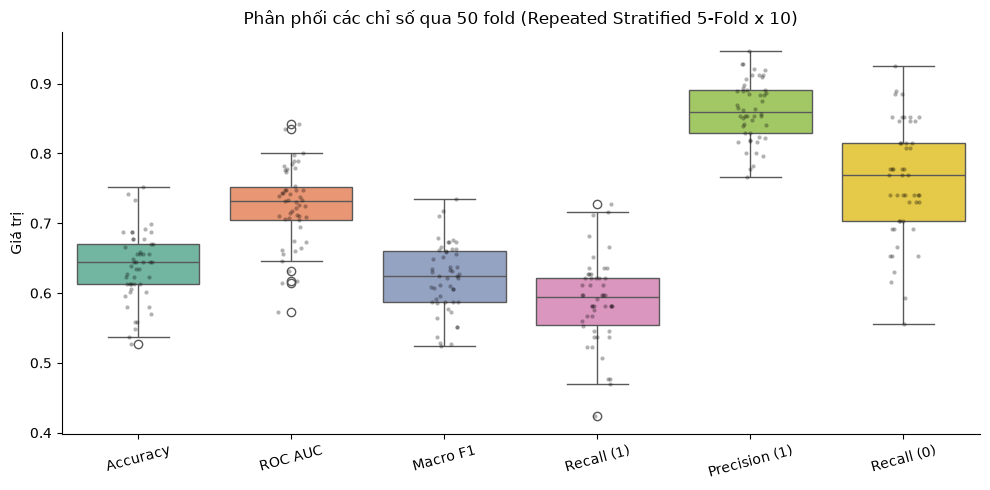

Kết quả nên báo cáo dạng mean ± std, không phải một con số trần trụi:
  Macro F1: 0.622 ± 0.049 (dao động 0.524 - 0.735 giữa các fold)
  ROC AUC: 0.725 ± 0.056 (dao động 0.573 - 0.843 giữa các fold)


In [5]:
# Repeated Stratified 5-Fold x 10 lần lặp trên TẬP TRAIN (50 lần khớp mô hình)
#
# Chọn 5-fold thay vì 10-fold: mỗi fold khi đó còn ~27 ca lớp 0 để chấm điểm;
# với 10-fold chỉ còn ~13 ca, recall(0) sẽ quá nhiễu để đọc.
# Lặp lại 10 lần với cách chia khác nhau để làm mượt ảnh hưởng của một lần chia cụ thể.
# Bắt buộc dùng bản Stratified vì tỉ lệ lớp là 71/29.
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_rows = []
for tr, te in rskf.split(X_train, y_train):
    fitted = build_and_fit(X_train[tr], y_train[tr])          # impute/scale/SMOTE nằm gọn trong đây
    proba = predict_proba_with(fitted, X_train[te])
    pred = (proba >= 0.5).astype(int)
    cv_rows.append(score_all(y_train[te], pred, proba))

cv_scores = pd.DataFrame(cv_rows)

cv_summary = pd.DataFrame({
    'Trung bình': cv_scores.mean(),
    'Độ lệch chuẩn': cv_scores.std(),
    'Thấp nhất': cv_scores.min(),
    'Cao nhất': cv_scores.max(),
})
print(f"Repeated Stratified 5-Fold x 10 ({len(cv_scores)} fold), ngưỡng mặc định 0.5:\n")
display(cv_summary.round(3))

# Phân phối điểm qua các fold: cho thấy một con số đơn lẻ từ holdout là không đủ
plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=cv_scores, palette='Set2', hue=None)
sns.stripplot(data=cv_scores, color='black', alpha=0.3, size=3, ax=ax)
ax.set_title(f'Phân phối các chỉ số qua {len(cv_scores)} fold (Repeated Stratified 5-Fold x 10)')
ax.set_ylabel('Giá trị')
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.show()

print("Kết quả nên báo cáo dạng mean ± std, không phải một con số trần trụi:")
for m in ['Macro F1', 'ROC AUC']:
    print(f"  {m}: {cv_scores[m].mean():.3f} ± {cv_scores[m].std():.3f} "
          f"(dao động {cv_scores[m].min():.3f} - {cv_scores[m].max():.3f} giữa các fold)")

In [6]:
# Khớp lại mô hình cuối cùng trên TOÀN BỘ tập train, rồi chấm điểm một lần trên tập test
final_fitted = build_and_fit(X_train, y_train)
proba_log = predict_proba_with(final_fitted, X_test)
y_pred_log = (proba_log >= 0.5).astype(int)

models_pred = {'Logistic Regression': y_pred_log}

for name, y_pred in models_pred.items():
    print(f"===== {name} (tập test, ngưỡng 0.5) =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Không bệnh (0)', 'Có bệnh (1)']))

# Đối chiếu: điểm trên test có nằm trong dải mà K-Fold đã dự báo không?
test_scores = pd.Series(score_all(y_test, y_pred_log, proba_log))
z = (test_scores - cv_scores.mean()) / cv_scores.std()

compare_cv_test = pd.DataFrame({
    'K-Fold (mean ± std)': cv_scores.mean().round(3).astype(str) + ' ± ' + cv_scores.std().round(3).astype(str),
    'Tập test (1 lần)': test_scores.round(3),
    'Lệch (số std)': z.round(2),
})
print("\nK-Fold trên train vs kết quả thực tế trên test:")
display(compare_cv_test)

n_far = int((z.abs() > 2).sum())
print(f"Số chỉ số lệch quá 2 std so với trung bình K-Fold: {n_far}/{len(z)}")
if n_far >= len(z) / 2:
    print("\n=> Phần lớn chỉ số trên test nằm NGOÀI dải mà K-Fold dự báo, và đều lệch về phía cao hơn.")
    print("   Đây không phải mô hình chạy tốt hơn, mà là tập test ứng với random_state=42 tình cờ")
    print("   'dễ' hơn mức trung bình. Nếu chỉ chạy holdout đơn rồi báo cáo con số đó, ta đã công bố")
    print("   một kết quả lạc quan mà không hề hay biết - chính là lý do cần K-Fold.")
    print(f"\n   Con số nên đưa vào tiểu luận là ước lượng từ K-Fold, ví dụ:")
    for m in ['Macro F1', 'ROC AUC']:
        print(f"     {m}: {cv_scores[m].mean():.3f} ± {cv_scores[m].std():.3f}  "
              f"(holdout đơn báo {test_scores[m]:.3f})")
else:
    print("\n=> Điểm trên test nằm trong dải K-Fold dự báo, ước lượng từ CV là nhất quán.")

===== Logistic Regression (tập test, ngưỡng 0.5) =====
Confusion Matrix:
[[28  6]
 [23 60]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.55      0.82      0.66        34
   Có bệnh (1)       0.91      0.72      0.81        83

      accuracy                           0.75       117
     macro avg       0.73      0.77      0.73       117
  weighted avg       0.80      0.75      0.76       117


K-Fold trên train vs kết quả thực tế trên test:


,K-Fold (mean ± std),Tập test (1 lần),Lệch (số std)
Accuracy,0.638 ± 0.05,0.752,2.28
ROC AUC,0.725 ± 0.056,0.841,2.07
Macro F1,0.622 ± 0.049,0.732,2.24
Recall (1),0.589 ± 0.061,0.723,2.18
Precision (1),0.862 ± 0.043,0.909,1.10
Recall (0),0.761 ± 0.083,0.824,0.76


Số chỉ số lệch quá 2 std so với trung bình K-Fold: 4/6

=> Phần lớn chỉ số trên test nằm NGOÀI dải mà K-Fold dự báo, và đều lệch về phía cao hơn.
   Đây không phải mô hình chạy tốt hơn, mà là tập test ứng với random_state=42 tình cờ
   'dễ' hơn mức trung bình. Nếu chỉ chạy holdout đơn rồi báo cáo con số đó, ta đã công bố
   một kết quả lạc quan mà không hề hay biết - chính là lý do cần K-Fold.

   Con số nên đưa vào tiểu luận là ước lượng từ K-Fold, ví dụ:
     Macro F1: 0.622 ± 0.049  (holdout đơn báo 0.732)
     ROC AUC: 0.725 ± 0.056  (holdout đơn báo 0.841)


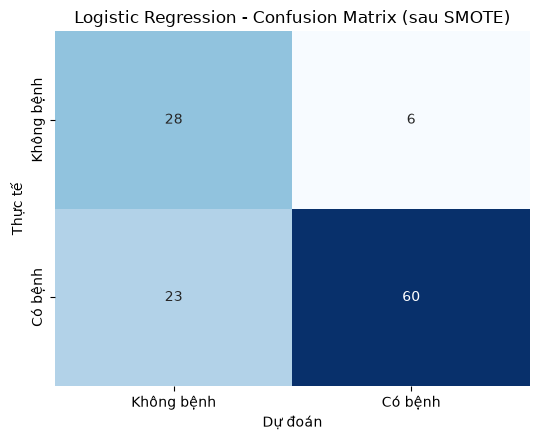

In [7]:
# Trực quan Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5.5, 4.5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                 xticklabels=['Không bệnh', 'Có bệnh'], yticklabels=['Không bệnh', 'Có bệnh'])
ax.set_title('Logistic Regression - Confusion Matrix (sau SMOTE)')
ax.set_xlabel('Dự đoán')
ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

In [8]:
# Bảng metrics tổng hợp cho Logistic Regression
rows = []
for name, y_pred in models_pred.items():
    report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
    rows.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (0)': report['0']['precision'],
        'Recall (0)': report['0']['recall'],
        'F1 (0)': report['0']['f1-score'],
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1 (1)': report['1']['f1-score'],
        'Macro F1': report['macro avg']['f1-score'],
    })

compare_df = pd.DataFrame(rows).set_index('Model').round(3)
compare_df

,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Macro F1
Model,,,,,,,,
Logistic Regression,0.752,0.549,0.824,0.659,0.909,0.723,0.805,0.732


## Chọn ngưỡng phân loại bằng dự đoán out-of-fold (recall lớp "có bệnh" ≥ 0.75)

Ngưỡng mặc định 0.5 tối ưu cho độ chính xác tổng thể, không ưu tiên riêng lớp nào. Trong bối cảnh y tế, bỏ sót một ca bệnh tốn kém hơn nhiều so với báo động nhầm một người khoẻ, nên ta hạ ngưỡng để đẩy recall lớp 1 lên.

**Ngưỡng phải được chọn trên tập train, không phải tập test.** Nếu dò ngưỡng trực tiếp trên test rồi báo cáo luôn kết quả ở ngưỡng đó, con số thu được là lạc quan giả tạo — ta đã dùng test hai lần, vừa để chỉnh tham số vừa để đánh giá.

Cách làm đúng ở đây: dùng `StratifiedKFold` để lấy **dự đoán out-of-fold** trên tập train (mỗi quan sát được dự đoán bởi mô hình chưa từng nhìn thấy nó), dò ngưỡng trên tập dự đoán đó, rồi mới áp ngưỡng cố định ấy lên tập test.

In [9]:
# Dò ngưỡng trên dự đoán out-of-fold của tập train, KHÔNG đụng vào tập test
from sklearn.metrics import precision_recall_curve

TARGET_RECALL = 0.75  # chỉnh ở đây nếu muốn đổi mức recall mục tiêu


def find_threshold_for_recall(y_true, y_proba, target_recall=TARGET_RECALL):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    valid = recall[:-1] >= target_recall
    if not valid.any():
        return thresholds.min(), recall[:-1].max()
    idx = np.where(valid)[0]
    best_idx = idx[np.argmax(thresholds[idx])]  # ngưỡng lớn nhất vẫn đạt recall mục tiêu -> precision tốt nhất có thể
    return thresholds[best_idx], recall[best_idx]


# Dự đoán out-of-fold: mỗi quan sát train được chấm bởi mô hình chưa từng thấy nó
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(y_train))
for tr, te in skf.split(X_train, y_train):
    oof_proba[te] = predict_proba_with(build_and_fit(X_train[tr], y_train[tr]), X_train[te])

thr, oof_recall = find_threshold_for_recall(y_train, oof_proba, TARGET_RECALL)
print(f"Ngưỡng chọn từ out-of-fold trên train: {thr:.3f} (recall out-of-fold = {oof_recall:.3f})")

# Áp ngưỡng cố định đó lên tập test - đây mới là ước lượng trung thực
models_pred_tuned = {'Logistic Regression': (proba_log >= thr).astype(int)}

print(f"\n===== Logistic Regression trên TEST tại ngưỡng {thr:.3f} =====")
print("Confusion Matrix:")
print(confusion_matrix(y_test, models_pred_tuned['Logistic Regression']))
print("\nClassification Report:")
print(classification_report(y_test, models_pred_tuned['Logistic Regression'],
                            target_names=['Không bệnh (0)', 'Có bệnh (1)']))

# --- Vì sao không được dò ngưỡng thẳng trên tập test ---
thr_cheat, _ = find_threshold_for_recall(y_test, proba_log, TARGET_RECALL)
recall_honest = recall_score(y_test, (proba_log >= thr).astype(int), pos_label=1)
recall_cheat = recall_score(y_test, (proba_log >= thr_cheat).astype(int), pos_label=1)

print(f"Ngưỡng dò từ out-of-fold (trung thực): {thr:.3f}  ->  recall(1) trên test = {recall_honest:.3f}")
print(f"Ngưỡng dò thẳng trên test (sai):       {thr_cheat:.3f}  ->  recall(1) trên test = {recall_cheat:.3f}")
print(f"\nLưu ý cách đọc: hàm dò ngưỡng ở đây THOẢ RÀNG BUỘC recall >= {TARGET_RECALL:.2f} chứ không")
print("tối đa hoá recall, nên cách sai không làm recall cao lên - nó làm recall bám sát mục tiêu")
print(f"{TARGET_RECALL:.2f} một cách hoàn hảo. Nhưng đó là hệ quả tất yếu của việc chọn ngưỡng ngay")
print("trên chính dữ liệu dùng để chấm điểm, KHÔNG phải bằng chứng mô hình tổng quát hoá tốt:")
print("áp ngưỡng đó lên bệnh nhân mới thì không có gì bảo đảm recall còn giữ được mức này.")
print(f"\nNgược lại, cách trung thực cho recall = {recall_honest:.3f}, lệch {recall_honest - TARGET_RECALL:+.3f}")
print("so với mục tiêu. Chính độ lệch đó mới là thông tin có giá trị: nó cho biết recall thực tế")
print("dao động cỡ nào khi chuyển sang dữ liệu chưa từng thấy.")

Ngưỡng chọn từ out-of-fold trên train: 0.372 (recall out-of-fold = 0.751)

===== Logistic Regression trên TEST tại ngưỡng 0.372 =====
Confusion Matrix:
[[19 15]
 [12 71]]

Classification Report:
                precision    recall  f1-score   support

Không bệnh (0)       0.61      0.56      0.58        34
   Có bệnh (1)       0.83      0.86      0.84        83

      accuracy                           0.77       117
     macro avg       0.72      0.71      0.71       117
  weighted avg       0.76      0.77      0.77       117

Ngưỡng dò từ out-of-fold (trung thực): 0.372  ->  recall(1) trên test = 0.855
Ngưỡng dò thẳng trên test (sai):       0.490  ->  recall(1) trên test = 0.759

Lưu ý cách đọc: hàm dò ngưỡng ở đây THOẢ RÀNG BUỘC recall >= 0.75 chứ không
tối đa hoá recall, nên cách sai không làm recall cao lên - nó làm recall bám sát mục tiêu
0.75 một cách hoàn hảo. Nhưng đó là hệ quả tất yếu của việc chọn ngưỡng ngay
trên chính dữ liệu dùng để chấm điểm, KHÔNG phải bằng chứng mô hìn

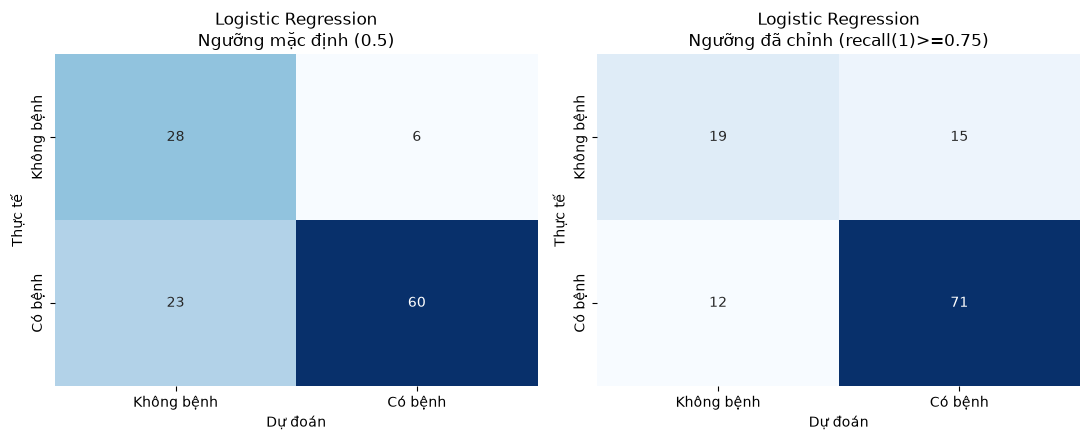

Accuracy  Recall (0)  Recall (1)  \
Model               Ngưỡng                                                      
Logistic Regression Mặc định (0.5)              0.752       0.824       0.723   
                    Đã chỉnh (recall>=0.75)     0.769       0.559       0.855   

                                             Precision (1)  Macro F1  
Model               Ngưỡng                                            
Logistic Regression Mặc định (0.5)                   0.909     0.732  
                    Đã chỉnh (recall>=0.75)          0.826     0.712

In [10]:
# So sánh trực quan: ngưỡng mặc định (0.5) vs ngưỡng đã chỉnh (recall >= TARGET_RECALL)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, y_pred) in zip(axes, [('Ngưỡng mặc định (0.5)', y_pred_log),
                                       (f'Ngưỡng đã chỉnh (recall(1)>={TARGET_RECALL:.2f})', models_pred_tuned['Logistic Regression'])]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Không bệnh', 'Có bệnh'], yticklabels=['Không bệnh', 'Có bệnh'], ax=ax)
    ax.set_title(f'Logistic Regression\n{title}')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

# Bảng so sánh metrics: mặc định vs đã chỉnh ngưỡng
rows = []
for name in models_pred:
    for variant, y_pred in [('Mặc định (0.5)', models_pred[name]),
                            (f'Đã chỉnh (recall>={TARGET_RECALL:.2f})', models_pred_tuned[name])]:
        report = classification_report(y_test, y_pred, target_names=['0', '1'], output_dict=True)
        rows.append({
            'Model': name, 'Ngưỡng': variant,
            'Accuracy': report['accuracy'],
            'Recall (0)': report['0']['recall'],
            'Recall (1)': report['1']['recall'],
            'Precision (1)': report['1']['precision'],
            'Macro F1': report['macro avg']['f1-score'],
        })

pd.DataFrame(rows).set_index(['Model', 'Ngưỡng']).round(3)

# Bootstrap: khoảng tin cậy cho các chỉ số

K-Fold ở trên trả lời câu "mô hình chạy tốt đến đâu". Bootstrap trả lời câu khác: **con số đó chính xác đến mức nào**.

Ý tưởng: tập test 117 quan sát chỉ là *một* mẫu rút từ quần thể bệnh nhân. Nếu lấy một mẫu 117 người khác, các chỉ số sẽ khác đi. Ta mô phỏng điều đó bằng cách rút lại có hoàn lại (resample with replacement) chính tập test B = 2000 lần, tính lại chỉ số mỗi lần, rồi lấy **phân vị 2.5% và 97.5%** của phân phối thu được làm khoảng tin cậy 95% (percentile bootstrap).

Điểm mạnh: cách này không cần giả định phân phối nào, và áp dụng được cho cả những chỉ số **không có công thức sai số chuẩn dạng đóng** như AUC hay macro F1.

In [11]:
# Percentile bootstrap: khoảng tin cậy 95% cho các chỉ số trên tập test
# (dùng lại score_all đã định nghĩa ở phần huấn luyện)
B = 2000
rng = np.random.default_rng(42)

y_true_arr = np.asarray(y_test)
n_test = len(y_true_arr)

point_est = score_all(y_true_arr, y_pred_log, proba_log)

boot_rows, skipped = [], 0
for _ in range(B):
    idx = rng.integers(0, n_test, n_test)          # rút có hoàn lại, cùng cỡ mẫu
    if len(np.unique(y_true_arr[idx])) < 2:        # mẫu suy biến (chỉ 1 lớp) -> AUC không định nghĩa được
        skipped += 1
        continue
    boot_rows.append(score_all(y_true_arr[idx], y_pred_log[idx], proba_log[idx]))

boot_df = pd.DataFrame(boot_rows)

ci = pd.DataFrame({
    'Điểm ước lượng': pd.Series(point_est),
    'CI 2.5%': boot_df.quantile(0.025),
    'CI 97.5%': boot_df.quantile(0.975),
    'SE bootstrap': boot_df.std(),
})
ci['Bề rộng CI'] = ci['CI 97.5%'] - ci['CI 2.5%']

print(f"Percentile bootstrap, B = {len(boot_df)} mẫu hợp lệ (bỏ {skipped} mẫu suy biến), n_test = {n_test}\n")
display(ci.round(3))

print("\nDiễn giải mẫu:")
for m in ['ROC AUC', 'Macro F1']:
    r = ci.loc[m]
    print(f"  {m} = {r['Điểm ước lượng']:.3f}, KTC 95% [{r['CI 2.5%']:.3f}, {r['CI 97.5%']:.3f}]")

# Đối chiếu hai cách định lượng độ bất định: Bootstrap (trên test) vs K-Fold (trên train)
print("\nSo sánh với độ lệch chuẩn thu được từ K-Fold:")
display(pd.DataFrame({
    'SE bootstrap (tập test)': ci['SE bootstrap'],
    'Std giữa các fold (K-Fold)': cv_scores.std(),
}).round(3))
print("Hai con số đo hai thứ khác nhau: bootstrap đo dao động do CHỌN MẪU TEST,")
print("còn std của K-Fold đo dao động do CHỌN TẬP HUẤN LUYỆN.")

Percentile bootstrap, B = 2000 mẫu hợp lệ (bỏ 0 mẫu suy biến), n_test = 117



,Điểm ước lượng,CI 2.5%,CI 97.5%,SE bootstrap,Bề rộng CI
Accuracy,0.752,0.675,0.829,0.040,0.154
ROC AUC,0.841,0.768,0.912,0.037,0.144
Macro F1,0.732,0.649,0.818,0.043,0.169
Recall (1),0.723,0.625,0.817,0.049,0.192
Precision (1),0.909,0.833,0.971,0.035,0.137
Recall (0),0.824,0.690,0.944,0.066,0.255



Diễn giải mẫu:
  ROC AUC = 0.841, KTC 95% [0.768, 0.912]
  Macro F1 = 0.732, KTC 95% [0.649, 0.818]

So sánh với độ lệch chuẩn thu được từ K-Fold:


,SE bootstrap (tập test),Std giữa các fold (K-Fold)
Accuracy,0.040,0.050
ROC AUC,0.037,0.056
Macro F1,0.043,0.049
Recall (1),0.049,0.061
Precision (1),0.035,0.043
Recall (0),0.066,0.083


Hai con số đo hai thứ khác nhau: bootstrap đo dao động do CHỌN MẪU TEST,
còn std của K-Fold đo dao động do CHỌN TẬP HUẤN LUYỆN.


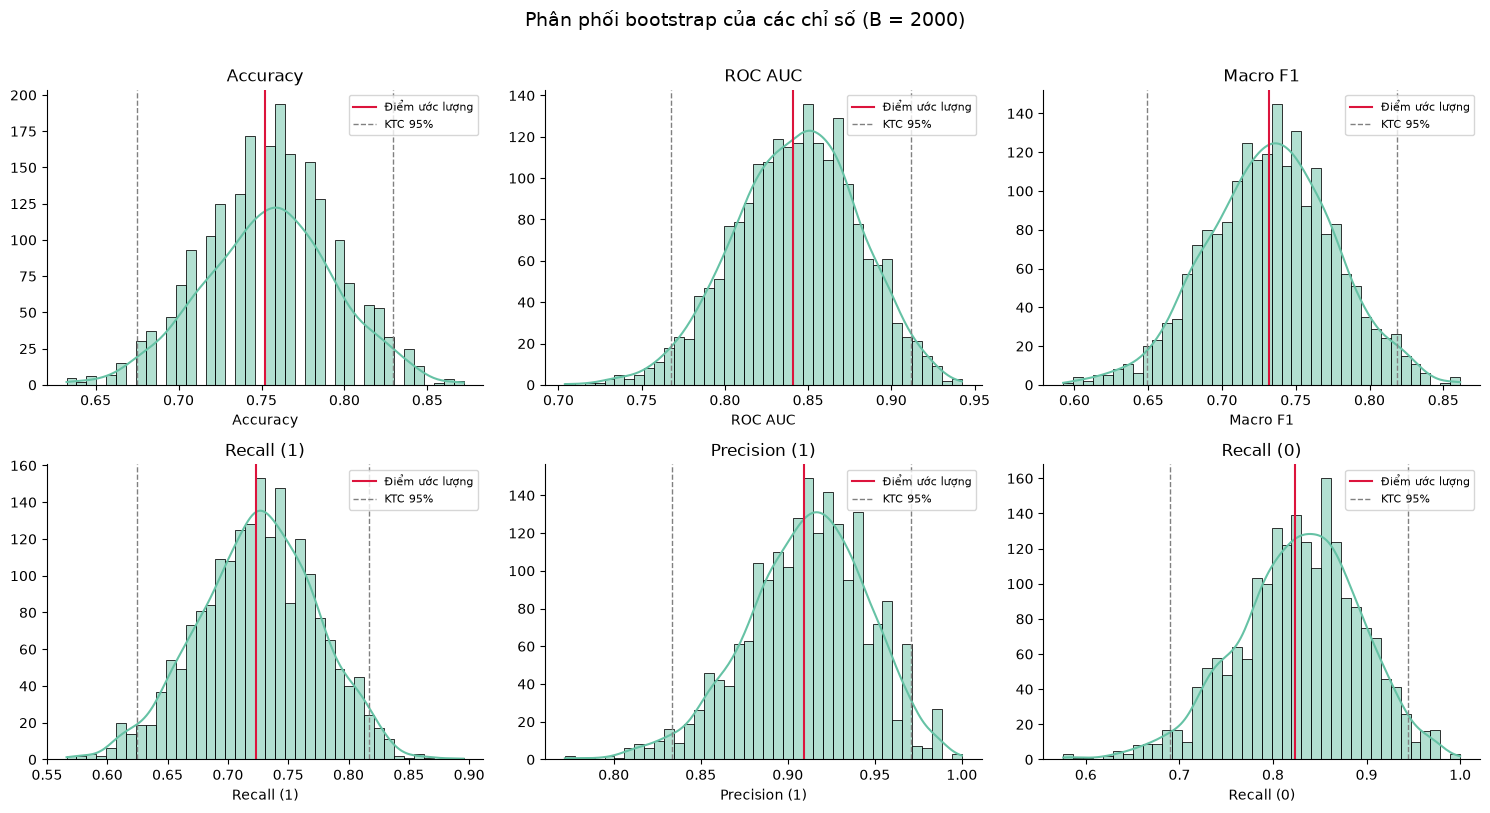

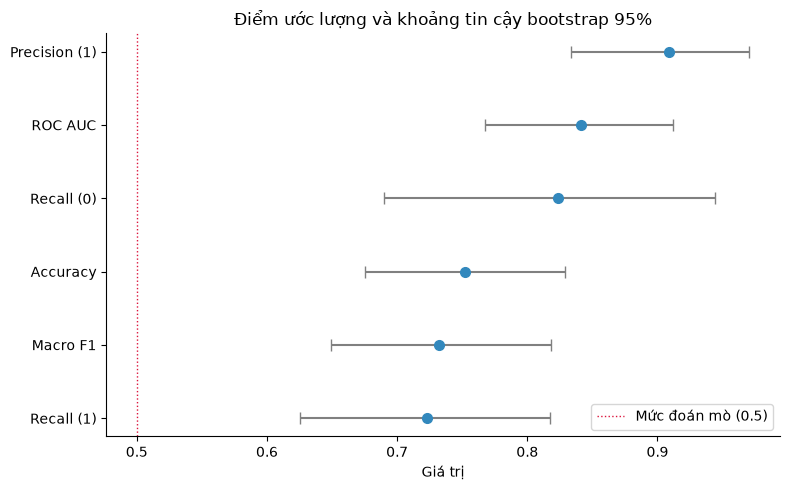

Chỉ số có khoảng tin cậy rộng nhất (kém tin cậy nhất):
Recall (0)    0.255
Recall (1)    0.192
Macro F1      0.169

Recall (0) thường rộng nhất vì chỉ dựa trên 34 ca lớp 0 trong tập test -
đúng vấn đề mà phần K-Fold phía trên đã chỉ ra.


In [12]:
# Trực quan hoá phân phối bootstrap và khoảng tin cậy
metrics = list(point_est.keys())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, m in zip(axes.flatten(), metrics):
    sns.histplot(boot_df[m], bins=40, kde=True, color='#66c2a5', ax=ax)
    ax.axvline(point_est[m], color='crimson', linestyle='-', linewidth=1.5, label='Điểm ước lượng')
    ax.axvline(ci.loc[m, 'CI 2.5%'], color='gray', linestyle='--', linewidth=1, label='KTC 95%')
    ax.axvline(ci.loc[m, 'CI 97.5%'], color='gray', linestyle='--', linewidth=1)
    ax.set_title(m)
    ax.set_ylabel('')
    ax.legend(fontsize=8)

plt.suptitle(f'Phân phối bootstrap của các chỉ số (B = {len(boot_df)})', y=1.01, fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

# Forest plot: điểm ước lượng kèm thanh khoảng tin cậy
order = ci.sort_values('Điểm ước lượng').index
plt.figure(figsize=(8, 5))
plt.errorbar(
    x=ci.loc[order, 'Điểm ước lượng'], y=range(len(order)),
    xerr=[ci.loc[order, 'Điểm ước lượng'] - ci.loc[order, 'CI 2.5%'],
          ci.loc[order, 'CI 97.5%'] - ci.loc[order, 'Điểm ước lượng']],
    fmt='o', color='#3288bd', ecolor='gray', capsize=4, markersize=7,
)
plt.yticks(range(len(order)), order)
plt.axvline(0.5, color='crimson', linestyle=':', linewidth=1, label='Mức đoán mò (0.5)')
plt.xlabel('Giá trị')
plt.title('Điểm ước lượng và khoảng tin cậy bootstrap 95%')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

print("Chỉ số có khoảng tin cậy rộng nhất (kém tin cậy nhất):")
print(ci['Bề rộng CI'].sort_values(ascending=False).head(3).round(3).to_string())
print("\nRecall (0) thường rộng nhất vì chỉ dựa trên 34 ca lớp 0 trong tập test -")
print("đúng vấn đề mà phần K-Fold phía trên đã chỉ ra.")